<a href="https://colab.research.google.com/github/Bat4E/Csci164-Colab/blob/main/Project164.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Necessary Packages**

In [ ]:
# Efrain Diaz Valdez, Herbart Hernandez, Daniel Zamora
# General libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing and machine learning
from sklearn.metrics import make_scorer, f1_score # Importing make_scorer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression, ElasticNet, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score, mean_squared_error,
    mean_absolute_error, r2_score, classification_report
)
from sklearn.inspection import permutation_importance

# Miscellaneous
from mpl_toolkits import mplot3d  # Herb's imports kept intact
from matplotlib.colors import ListedColormap  # Preserved from Herb's code

# Additional libraries used by Herb
try:
    !pip install ucimlrepo  # Only if it hasn't been installed yet
except:
    print("Failed to install ucimlrepo.")
from ucimlrepo import fetch_ucirepo

# Additional libraries used by Zamora
try:
    !gdown 1S3TkWz-iw72id-eT6MyfgaFxV2LgOwaw
except:
    print("Ensure `gdown` is installed for downloading datasets.")

Downloading...
From: https://drive.google.com/uc?id=1S3TkWz-iw72id-eT6MyfgaFxV2LgOwaw
To: /content/SupplyChainGHGEmissionFactors_v1.2_NAICS_CO2e_USD2021.csv
100% 123k/123k [00:00<00:00, 76.1MB/s]


**Loading Lung Cancer Dataset & Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load Lung Cancer dataset from Google Drive
data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/lcs_synthetic_20000.csv')

# Display the first few rows of the dataset
print(data.head())
print(data.info())

Mounted at /content/drive
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        2               1        1              2   
1      M   71        2               2        1              1   
2      M   61        2               1        1              2   
3      M   55        2               2        1              2   
4      F   56        2               1        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         1                  2         2   
1                2         1         2         2                  1         1   
2                2         1         2         2                  1         1   
3                1         1         1         2                  2         1   
4                1         2         2         2                  2         1   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0                 

**Creating Dataset Copies**

In [ ]:
# Create copies of the dataset for Logistic Regression and Linear Regression
data_logistic = data.copy() # For binary classification
data_linear = data.copy() # For numerical prediction

**Preprocess for Classification Tasks**

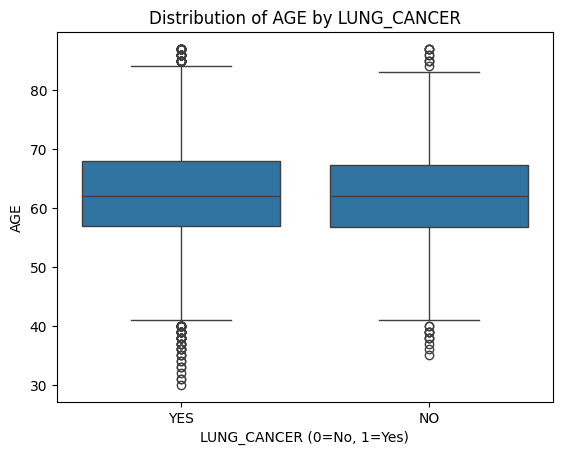

Class distribution in y_test_logistic:
(array(['NO', 'YES'], dtype=object), array([ 514, 3486]))


In [ ]:
# Binary encoding: From 1=No, 2=Yes to 0=No, 1=Yes
data_logistic.replace({1: 0, 2: 1}, inplace=True)

# Encode GENDER using Label Encoding
le = LabelEncoder()
data_logistic['GENDER'] = le.fit_transform(data_logistic['GENDER'])

# Visualize feature distribution across classes using a boxplot
sns.boxplot(x='LUNG_CANCER', y='AGE', data=data_logistic)
plt.title("Distribution of AGE by LUNG_CANCER")
plt.xlabel("LUNG_CANCER (0=No, 1=Yes)")
plt.ylabel("AGE")
plt.show()

# Feature-target split
X_logistic = data_logistic.drop('LUNG_CANCER', axis=1)
y_logistic = data_logistic['LUNG_CANCER']

# Train-test split with stratified sampling to preserve class distribution
X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic = train_test_split(
    X_logistic, y_logistic, test_size=0.2, random_state=42, stratify=y_logistic
)

# Debugging: Verify class distribution in the test set
print("Class distribution in y_test_logistic:")
print(np.unique(y_test_logistic, return_counts=True))

# Standardize AGE
scaler = StandardScaler()
X_train_logistic['AGE'] = scaler.fit_transform(X_train_logistic[['AGE']])
X_test_logistic['AGE'] = scaler.transform(X_test_logistic[['AGE']])

**Verifying and Debugging for Preprocessing (Classification)**

In [ ]:
# Verify Preprocessing for Classification Tasks
print("Classification Tasks Preprocessed Data (Preview):")
print(data_logistic.head())

Classification Tasks Preprocessed Data (Preview):
   GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0       1   69        1               0        0              1   
1       1   71        1               1        0              0   
2       1   61        1               0        0              1   
3       1   55        1               1        0              1   
4       0   56        1               0        0              0   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                0         1         0         0                  1         1   
1                1         0         1         1                  0         0   
2                1         0         1         1                  0         0   
3                0         0         0         1                  1         0   
4                0         1         1         1                  1         0   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LU

**Logistic Regression: Model Fitting**

In [ ]:
# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

# Define custom scoring with pos_label
scorer = make_scorer(f1_score, pos_label='YES')

# Set up GridSearchCV
grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid,
    scoring=scorer,
    cv=5
)

# Fit GridSearchCV to training data
grid_search.fit(X_train_logistic, y_train_logistic)

# Display best parameters
print("\nBest Parameters:", grid_search.best_params_)

# Used best model identified by GridSearchCV
model_logistic = grid_search.best_estimator_

# Confirm the training is complete
print("\nLogistic Regression Model Training Complete (with GridSearchCV)!")


# Analyze and display feature importance
print("\nFeature Importance Coefficients:")
feature_importance = dict(zip(X_logistic.columns, model_logistic.coef_[0]))
for feature, coef in feature_importance.items():
    print(f"{feature}: {coef:.4f}")


Best Parameters: {'C': 10.0, 'solver': 'lbfgs'}

Logistic Regression Model Training Complete (with GridSearchCV)!

Feature Importance Coefficients:
GENDER: -0.0680
AGE: 0.0454
SMOKING: 0.0072
YELLOW_FINGERS: -0.0158
ANXIETY: -0.0140
PEER_PRESSURE: -0.0110
CHRONIC DISEASE: -0.0166
FATIGUE : -0.0160
ALLERGY : -0.0470
WHEEZING: -0.0544
ALCOHOL CONSUMING: -0.0324
COUGHING: 0.0443
SHORTNESS OF BREATH: 0.0777
SWALLOWING DIFFICULTY: -0.0603
CHEST PAIN: -0.0752


**K-NN: Model Fitting**

In [ ]:
# K-Nearest Neighbors: Hyperparameter Tuning

# Define hyperparameter grid for k-NN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Set up GridSearchCV for k-NN
grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    scoring=scorer,  # Using the same F1-score custom scorer
    cv=5
)

# Fit GridSearchCV to training data
grid_search_knn.fit(X_train_logistic, y_train_logistic)

# Display best parameters
print("\nBest Parameters for k-NN:", grid_search_knn.best_params_)

# Use the best model for predictions
knn = grid_search_knn.best_estimator_

# Confirm the training is complete
print("\nk-NN Model Training Complete (with GridSearchCV)!")


Best Parameters for k-NN: {'metric': 'manhattan', 'n_neighbors': 11}

k-NN Model Training Complete (with GridSearchCV)!


**Verification After Model Fitting**

In [ ]:
# Check Logistic Regression coefficients to interpret feature importance
print("\nLogistic Regression Coefficients:")
print(model_logistic.coef_)


Logistic Regression Coefficients:
[[-0.06802461  0.04537543  0.00719703 -0.01584201 -0.01404389 -0.01095737
  -0.01656445 -0.01595873 -0.04703055 -0.05437156 -0.0324009   0.04434725
   0.07772127 -0.06034435 -0.07516723]]


**Logistic Regression Validation**


Predicted Probabilities for 'YES': [0.53817688 0.49544599 0.55768174 0.46730405 0.4701006  0.48356237
 0.46306779 0.50907423 0.52078463 0.49406605]


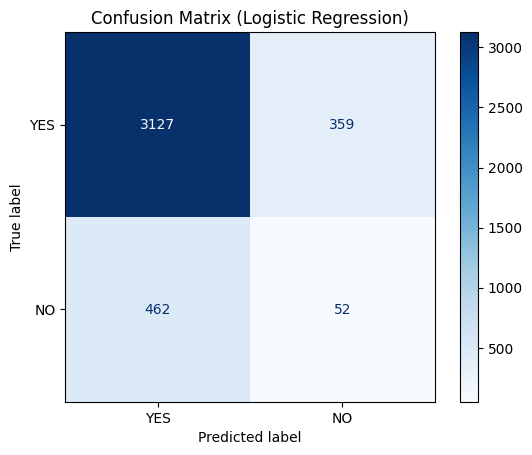


Confusion Matrix Values:
True Positives (TP): 3127
False Positives (FP): 462
True Negatives (TN): 52
False Negatives (FN): 359

Evaluating Logistic Regression with Metrics:
Accuracy: 0.79475
Precision: 0.8712733351908609
Recall: 0.8970166379804934
F1 Score: 0.8839575971731449


In [ ]:
# Predict probabilities on the test set
y_pred_proba_logistic = model_logistic.predict_proba(X_test_logistic)[:, 1]

# Use threshold for predictions
threshold = 0.47  # Adjusted threshold
y_pred_logistic = np.where(y_pred_proba_logistic >= threshold, 'YES', 'NO')

# Debugging: Verify predicted probabilities
print("\nPredicted Probabilities for 'YES':", y_pred_proba_logistic[:10])  # Preview the first 10 probabilities

# Compute and visualize the confusion matrix
cm = confusion_matrix(y_test_logistic, y_pred_logistic, labels=['YES', 'NO'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['YES', 'NO'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

# Print the confusion matrix values
print("\nConfusion Matrix Values:")
print("True Positives (TP):", cm[0, 0])
print("False Positives (FP):", cm[1, 0])
print("True Negatives (TN):", cm[1, 1])
print("False Negatives (FN):", cm[0, 1])

# Additional validation metrics
print("\nEvaluating Logistic Regression with Metrics:")
print("Accuracy:", accuracy_score(y_test_logistic, y_pred_logistic))
print("Precision:", precision_score(y_test_logistic, y_pred_logistic, pos_label='YES', zero_division=0))
print("Recall:", recall_score(y_test_logistic, y_pred_logistic, pos_label='YES', zero_division=0))
print("F1 Score:", f1_score(y_test_logistic, y_pred_logistic, pos_label='YES', zero_division=0))

****

**K-NN Validation**

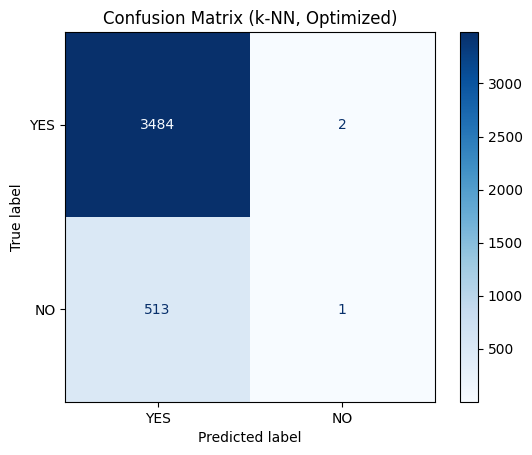


Confusion Matrix Values (k-NN, Optimized):
True Positives (TP): 3484
False Positives (FP): 513
True Negatives (TN): 1
False Negatives (FN): 2

Evaluating Optimized k-NN with Metrics:
Accuracy: 0.87125
Precision: 0.8716537403052289
Recall: 0.9994262765347103
F1 Score: 0.9311773352933316


In [ ]:
# K-NN Validation with Best Model

# Predict using the optimized k-NN model
y_pred_knn = knn.predict(X_test_logistic)

# Compute confusion matrix
cm_knn = confusion_matrix(y_test_logistic, y_pred_knn, labels=['YES', 'NO'])
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['YES', 'NO'])
disp_knn.plot(cmap='Blues')
plt.title("Confusion Matrix (k-NN, Optimized)")
plt.show()

# Print confusion matrix values
print("\nConfusion Matrix Values (k-NN, Optimized):")
print("True Positives (TP):", cm_knn[0, 0])
print("False Positives (FP):", cm_knn[1, 0])
print("True Negatives (TN):", cm_knn[1, 1])
print("False Negatives (FN):", cm_knn[0, 1])

# Evaluate metrics for optimized k-NN
print("\nEvaluating Optimized k-NN with Metrics:")
print("Accuracy:", accuracy_score(y_test_logistic, y_pred_knn))
print("Precision:", precision_score(y_test_logistic, y_pred_knn, pos_label='YES', zero_division=0))
print("Recall:", recall_score(y_test_logistic, y_pred_knn, pos_label='YES', zero_division=0))
print("F1 Score:", f1_score(y_test_logistic, y_pred_knn, pos_label='YES', zero_division=0))

**Logistic Regression Evaluation**

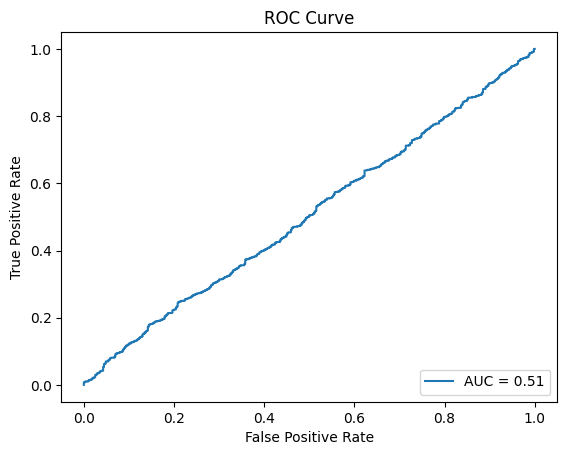

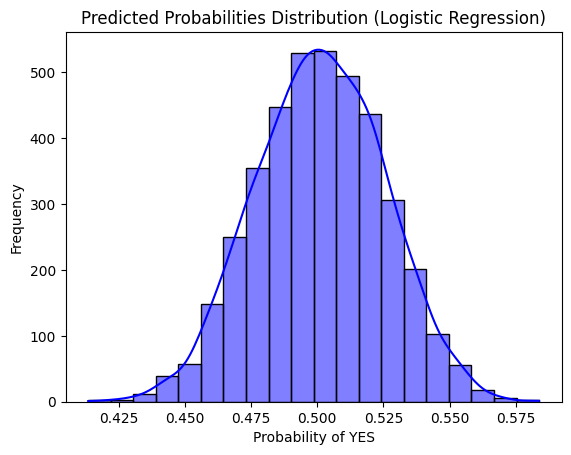

In [ ]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_logistic, y_pred_proba_logistic, pos_label='YES')

# Plot ROC curve
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_logistic, y_pred_proba_logistic):.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Plot the distribution of predicted probabilities
sns.histplot(y_pred_proba_logistic, bins=20, kde=True, color='blue')
plt.title("Predicted Probabilities Distribution (Logistic Regression)")
plt.xlabel("Probability of YES")
plt.ylabel("Frequency")
plt.show()

**K-NN Evaluation**

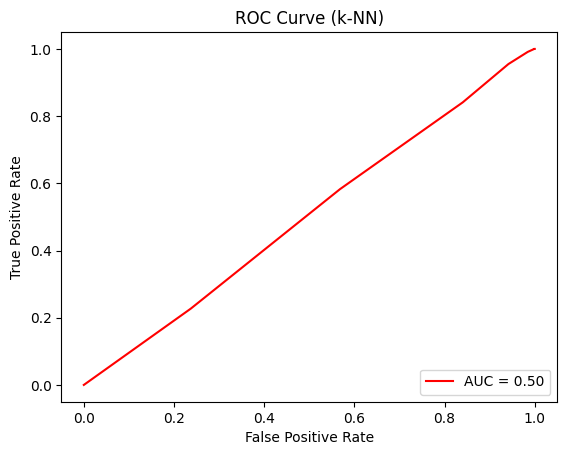

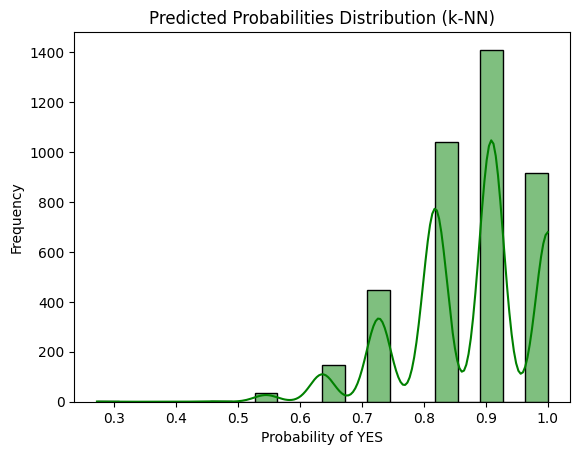

In [ ]:
# Calculate ROC curve for k-NN
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test_logistic, knn.predict_proba(X_test_logistic)[:, 1], pos_label='YES')

# Plot ROC curve
plt.plot(fpr_knn, tpr_knn, label=f"AUC = {roc_auc_score(y_test_logistic, knn.predict_proba(X_test_logistic)[:, 1]):.2f}", color='red')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (k-NN)")
plt.legend(loc="lower right")
plt.show()

# Plot distribution of predicted probabilities for k-NN
sns.histplot(knn.predict_proba(X_test_logistic)[:, 1], bins=20, kde=True, color='green')
plt.title("Predicted Probabilities Distribution (k-NN)")
plt.xlabel("Probability of YES")
plt.ylabel("Frequency")
plt.show()

**Model Comparison: Logistic Regression & KNN**

Comparing Model Metrics:
      Metric  Logistic Regression      k-NN
0   Accuracy             0.794750  0.871250
1  Precision             0.871273  0.871654
2     Recall             0.897017  0.999426
3   F1 Score             0.883958  0.931177
4    ROC-AUC             0.505029  0.502767


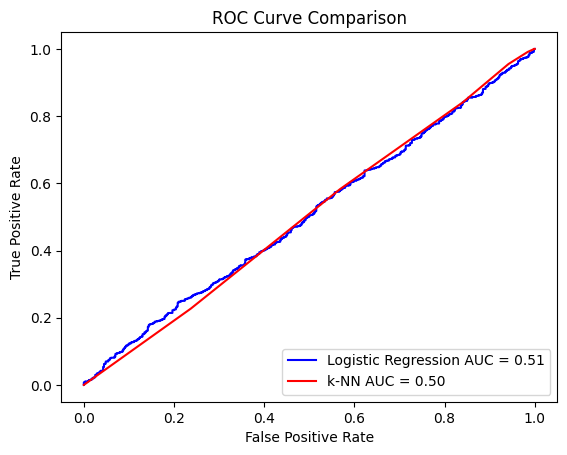

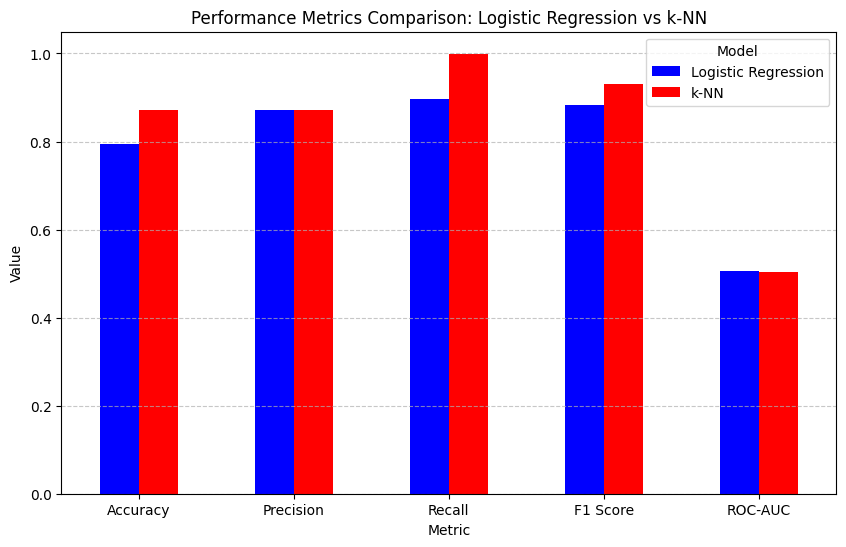

In [ ]:
# Model Comparison

print("Comparing Model Metrics:")

# Create a compact table for comparison
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy_score(y_test_logistic, y_pred_logistic),
        precision_score(y_test_logistic, y_pred_logistic, pos_label='YES', zero_division=0),
        recall_score(y_test_logistic, y_pred_logistic, pos_label='YES', zero_division=0),
        f1_score(y_test_logistic, y_pred_logistic, pos_label='YES', zero_division=0),
        roc_auc_score(y_test_logistic, y_pred_proba_logistic)
    ],
    "k-NN": [
        accuracy_score(y_test_logistic, y_pred_knn),
        precision_score(y_test_logistic, y_pred_knn, pos_label='YES', zero_division=0),
        recall_score(y_test_logistic, y_pred_knn, pos_label='YES', zero_division=0),
        f1_score(y_test_logistic, y_pred_knn, pos_label='YES', zero_division=0),
        roc_auc_score(y_test_logistic, knn.predict_proba(X_test_logistic)[:, 1])
    ]
}

# Convert to a DataFrame for easier formatting
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

# Visual Comparison using ROC Curves

# Combined ROC Curve for Both Models
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {roc_auc_score(y_test_logistic, y_pred_proba_logistic):.2f}", color='blue')
plt.plot(fpr_knn, tpr_knn, label=f"k-NN AUC = {roc_auc_score(y_test_logistic, knn.predict_proba(X_test_logistic)[:, 1]):.2f}", color='red')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

# Visual Comparison using a Bar Graph

# Set the index to "Metric" for easier plotting
comparison_df.set_index("Metric", inplace=True)

# Plot the bar graph
comparison_df.plot(kind="bar", figsize=(10, 6), color=["blue", "red"])
plt.title("Performance Metrics Comparison: Logistic Regression vs k-NN")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.xticks(rotation=0)  # Keep metric labels horizontal for better readability
plt.legend(title="Model", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

**SUPERVISED LEARNING: REGRESSORS**

**Preprocess for Supervised Regressors**

In [ ]:
# Binary Encoding
data_linear.replace({'YES': 1, 'NO': 0}, inplace=True) # Explicitly handle 'YES' and 'NO'
data_linear.replace({1: 0, 2: 1}, inplace=True) # Previous encoding for other binary values

# Encode GENDER
data_linear['GENDER'] = le.fit_transform(data_linear['GENDER'])

# Scale AGE
data_linear['AGE'] = scaler.fit_transform(data_linear[['AGE']])

# Feature-target split
X_linear = data_linear.drop('AGE', axis=1)
y_linear = data_linear['AGE'] # Numerical target

# Train-test split
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42
)

<ipython-input-14-b7895db87c5c>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_linear.replace({'YES': 1, 'NO': 0}, inplace=True) # Explicitly handle 'YES' and 'NO'


**Verifying and Debugging for Preprocessing (Regression)**

In [ ]:
# Verify Preprocessing for Linear Regression
print("\nLinear Regression Preprocessed Data (Preview):")
print(data_linear.head())


Linear Regression Preprocessed Data (Preview):
   GENDER       AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0       1  0.828319        1               0        0              1   
1       1  1.072043        1               1        0              0   
2       1 -0.146575        1               0        0              1   
3       1 -0.877746        1               1        0              1   
4       0 -0.755885        1               0        0              0   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                0         1         0         0                  1         1   
1                1         0         1         1                  0         0   
2                1         0         1         1                  0         0   
3                0         0         0         1                  1         0   
4                0         1         1         1                  1         0   

   SHORTNESS OF BREATH  SWALLOWI

**Code for Elastic Net Regression**


Best Parameters for Elastic Net Regression: {'alpha': 0.01, 'l1_ratio': 0.5}

Elastic Net Regression Evaluation Metrics:
R-Squared (R2-Score): -0.00029216163705303444
Mean Squared Error (MSE): 1.0010592968341308


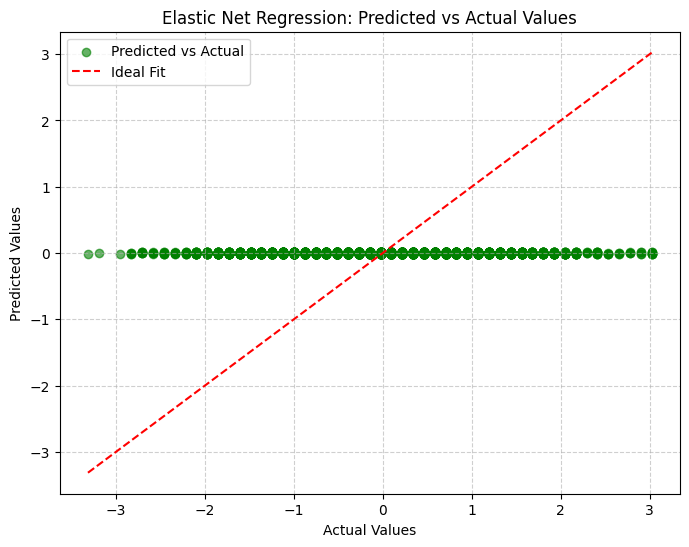

In [ ]:
# Define hyperparameter grid for Elastic Net
param_grid_elastic = {
    'alpha': [0.001, 0.005, 0.01, 0.05, 0.1],  # Range of regularization strengths
    'l1_ratio': [0.1, 0.5, 0.9]  # Balance between L1 and L2 penalties
}

# Set up GridSearchCV
elastic_grid_search = GridSearchCV(
    ElasticNet(random_state=42),
    param_grid_elastic,
    scoring='neg_mean_squared_error',  # Use MSE as the evaluation metric
    cv=5  # 5-fold cross-validation
)

# Fit GridSearchCV to training data
elastic_grid_search.fit(X_train_linear, y_train_linear)

# Get the best hyperparameters
print("\nBest Parameters for Elastic Net Regression:", elastic_grid_search.best_params_)

# Use the best model for predictions
elastic_best = elastic_grid_search.best_estimator_
y_pred_elastic = elastic_best.predict(X_test_linear)

# Evaluate Metrics for Elastic Net Regression
print("\nElastic Net Regression Evaluation Metrics:")
print("R-Squared (R2-Score):", r2_score(y_test_linear, y_pred_elastic))
print("Mean Squared Error (MSE):", mean_squared_error(y_test_linear, y_pred_elastic))

# Visualize Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_linear, y_pred_elastic, alpha=0.6, color='green', label='Predicted vs Actual')
plt.plot([min(y_test_linear), max(y_test_linear)], [min(y_test_linear), max(y_test_linear)], color='red', linestyle='--', label='Ideal Fit')
plt.title("Elastic Net Regression: Predicted vs Actual Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**KNN-Regressors**


Best Parameters for k-NN Regression: {'metric': 'euclidean', 'n_neighbors': 11}

K-NN Regression Evaluation Metrics:
R-Squared (R2-Score): -0.09238117117123745
Mean Squared Error (MSE): 1.093218930455144


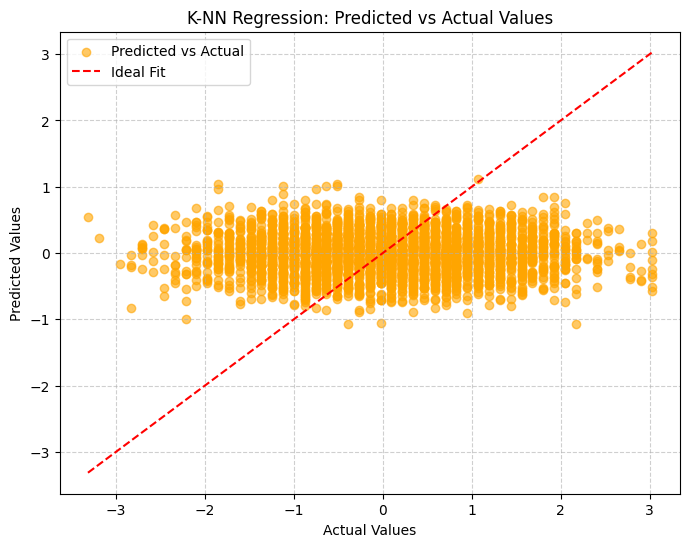

In [ ]:
# Define hyperparameter grid for k-NN Regression
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Range of k values to try
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Different distance metrics
}

# Set up GridSearchCV
knn_grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    scoring='neg_mean_squared_error',  # Use MSE as the evaluation metric
    cv=5  # 5-fold cross-validation
)

# Fit GridSearchCV to training data
knn_grid_search.fit(X_train_linear, y_train_linear)

# Get the best hyperparameters
print("\nBest Parameters for k-NN Regression:", knn_grid_search.best_params_)

# Use the best model for predictions
knn_best = knn_grid_search.best_estimator_
y_pred_knn = knn_best.predict(X_test_linear)

# Evaluate Metrics for k-NN Regression
print("\nK-NN Regression Evaluation Metrics:")
print("R-Squared (R2-Score):", r2_score(y_test_linear, y_pred_knn))
print("Mean Squared Error (MSE):", mean_squared_error(y_test_linear, y_pred_knn))

# Visualize Predicted vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_linear, y_pred_knn, alpha=0.6, color='orange', label='Predicted vs Actual')
plt.plot([min(y_test_linear), max(y_test_linear)], [min(y_test_linear), max(y_test_linear)], color='red', linestyle='--', label='Ideal Fit')
plt.title("K-NN Regression: Predicted vs Actual Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

The Dataset "Lung Cancer" lacks features in order to be used for any Supervised Learning Regressor Task. A good idea would be to add a feature that provides smoking time, how long and how many. Perhaps even a feature of environment conditions aka pollution levels.

**THIS IS THE HERB'S DATASET: WINE**

In [ ]:
# Fetch the Wine Quality dataset
wine_quality = fetch_ucirepo(id=186)
X_wine = pd.DataFrame(wine_quality.data.features)
y_wine = pd.DataFrame(wine_quality.data.original[['quality', 'color']])

# Clean and standardize the dataset
scaler_wine = StandardScaler()
X_wine_scaled = pd.DataFrame(scaler_wine.fit_transform(X_wine), columns=X_wine.columns)

# Setup for Task 1: Wine Color Classification
X_color_wine = X_wine_scaled
y_color_wine = y_wine['color']

# Setup for Task 2: Wine Quality Regression
X_quality_wine = X_wine_scaled
y_quality_wine = y_wine['quality']

# Train-test split for Color Classification
X_color_train_wine, X_color_test_wine, y_color_train_wine, y_color_test_wine = train_test_split(
    X_color_wine, y_color_wine, test_size=0.2, random_state=42
)

# Train-test split for Quality Regression
X_quality_train_wine, X_quality_test_wine, y_quality_train_wine, y_quality_test_wine = train_test_split(
    X_quality_wine, y_quality_wine, test_size=0.2, random_state=42
)

# Verify splits
print("\nColor Classification Task:")
print(f"Training set: {X_color_train_wine.shape}, {y_color_train_wine.shape}")
print(f"Testing set: {X_color_test_wine.shape}, {y_color_test_wine.shape}")

print("\nQuality Regression Task:")
print(f"Training set: {X_quality_train_wine.shape}, {y_quality_train_wine.shape}")
print(f"Testing set: {X_quality_test_wine.shape}, {y_quality_test_wine.shape}")



Color Classification Task:
Training set: (5197, 11), (5197,)
Testing set: (1300, 11), (1300,)

Quality Regression Task:
Training set: (5197, 11), (5197,)
Testing set: (1300, 11), (1300,)


**HERB: WINE REGRESSION MODELS**


----- WINE QUALITY REGRESSION MODELS -----

Best number of neighbors (k): 12
Best CV score: 0.4908 (MSE)

Wine's KNN Regressor Metrics:
Mean Squared Error (MSE): 0.4930
Root Mean Squared Error (RMSE): 0.7022
R² Score: 0.3324


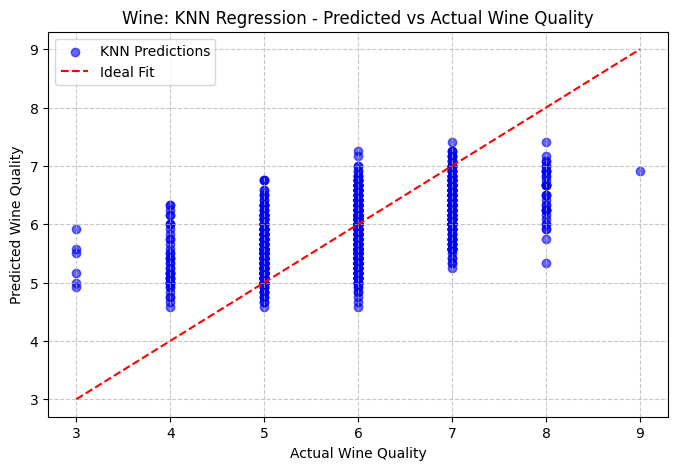


Wine's Linear Regressor Metrics:
Mean Squared Error (MSE): 0.5467
Root Mean Squared Error (RMSE): 0.7394
R² Score: 0.2598


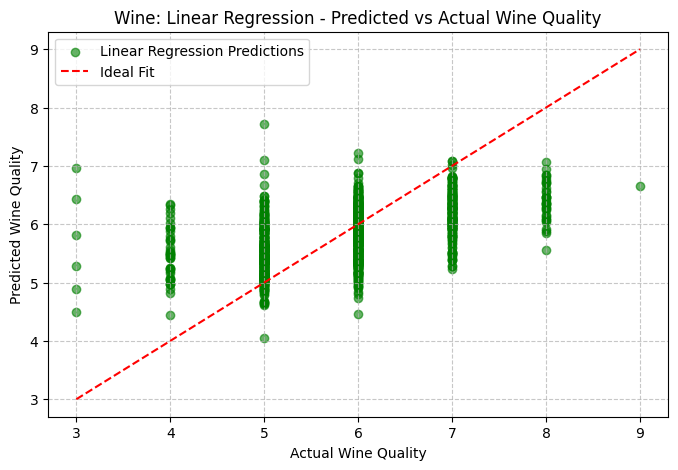

In [ ]:
# --------------------- WINE: REGRESSION MODELS ---------------------
print("\n----- WINE QUALITY REGRESSION MODELS -----")

# KNN Regressor for wine quality
param_grid_wine_knn = {'n_neighbors': range(1, 21)}
herb_grid_search_wine_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_wine_knn,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
herb_grid_search_wine_knn.fit(X_quality_train_wine, y_quality_train_wine)

# Get the best k value
herb_best_k_wine = herb_grid_search_wine_knn.best_params_['n_neighbors']
print(f"\nBest number of neighbors (k): {herb_best_k_wine}")
print(f"Best CV score: {-herb_grid_search_wine_knn.best_score_:.4f} (MSE)")

# Final KNN Regressor
herb_KNNRegressor = KNeighborsRegressor(n_neighbors=herb_best_k_wine)
herb_KNNRegressor.fit(X_quality_train_wine, y_quality_train_wine)

# Evaluate metrics
herb_y_pred_knn = herb_KNNRegressor.predict(X_quality_test_wine)
herb_mse_knn = mean_squared_error(y_quality_test_wine, herb_y_pred_knn)
herb_rmse_knn = np.sqrt(herb_mse_knn)
herb_r2_knn = r2_score(y_quality_test_wine, herb_y_pred_knn)

print("\nWine's KNN Regressor Metrics:")
print(f"Mean Squared Error (MSE): {herb_mse_knn:.4f}")
print(f"Root Mean Squared Error (RMSE): {herb_rmse_knn:.4f}")
print(f"R² Score: {herb_r2_knn:.4f}")

# Visualize Predicted vs Actual for KNN Regressor
plt.figure(figsize=(8, 5))
plt.scatter(y_quality_test_wine, herb_y_pred_knn, alpha=0.6, label='KNN Predictions', color='blue')
plt.plot([y_quality_test_wine.min(), y_quality_test_wine.max()], [y_quality_test_wine.min(), y_quality_test_wine.max()],
         color='red', linestyle='--', label='Ideal Fit')
plt.title('Wine: KNN Regression - Predicted vs Actual Wine Quality')
plt.xlabel('Actual Wine Quality')
plt.ylabel('Predicted Wine Quality')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Linear Regression for wine quality
herb_LinearRegressor = LinearRegression()
herb_LinearRegressor.fit(X_quality_train_wine, y_quality_train_wine)

# Evaluate Linear Regression
herb_y_pred_lin = herb_LinearRegressor.predict(X_quality_test_wine)
herb_mse_lin = mean_squared_error(y_quality_test_wine, herb_y_pred_lin)
herb_rmse_lin = np.sqrt(herb_mse_lin)
herb_r2_lin = r2_score(y_quality_test_wine, herb_y_pred_lin)

print("\nWine's Linear Regressor Metrics:")
print(f"Mean Squared Error (MSE): {herb_mse_lin:.4f}")
print(f"Root Mean Squared Error (RMSE): {herb_rmse_lin:.4f}")
print(f"R² Score: {herb_r2_lin:.4f}")

# Visualize Predicted vs Actual for Linear Regressor
plt.figure(figsize=(8, 5))
plt.scatter(y_quality_test_wine, herb_y_pred_lin, alpha=0.6, label='Linear Regression Predictions', color='green')
plt.plot([y_quality_test_wine.min(), y_quality_test_wine.max()], [y_quality_test_wine.min(), y_quality_test_wine.max()],
         color='red', linestyle='--', label='Ideal Fit')
plt.title('Wine: Linear Regression - Predicted vs Actual Wine Quality')
plt.xlabel('Actual Wine Quality')
plt.ylabel('Predicted Wine Quality')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

**Wine: CLASSIFICATION MODELS**


----- WINE COLOR CLASSIFICATION MODELS -----

Wine's KNN Classifier Results:
Accuracy: 0.9900

Confusion Matrix:
[[333   8]
 [  5 954]]

Classification Report:
              precision    recall  f1-score   support

         red       0.99      0.98      0.98       341
       white       0.99      0.99      0.99       959

    accuracy                           0.99      1300
   macro avg       0.99      0.99      0.99      1300
weighted avg       0.99      0.99      0.99      1300


--- Wine Logistic Regression Classifier ---

Wine's Logistic Regression Accuracy: 0.9877

Wine Confusion Matrix:
[[332   9]
 [  7 952]]

Wine Classification Report:
              precision    recall  f1-score   support

         red       0.98      0.97      0.98       341
       white       0.99      0.99      0.99       959

    accuracy                           0.99      1300
   macro avg       0.98      0.98      0.98      1300
weighted avg       0.99      0.99      0.99      1300



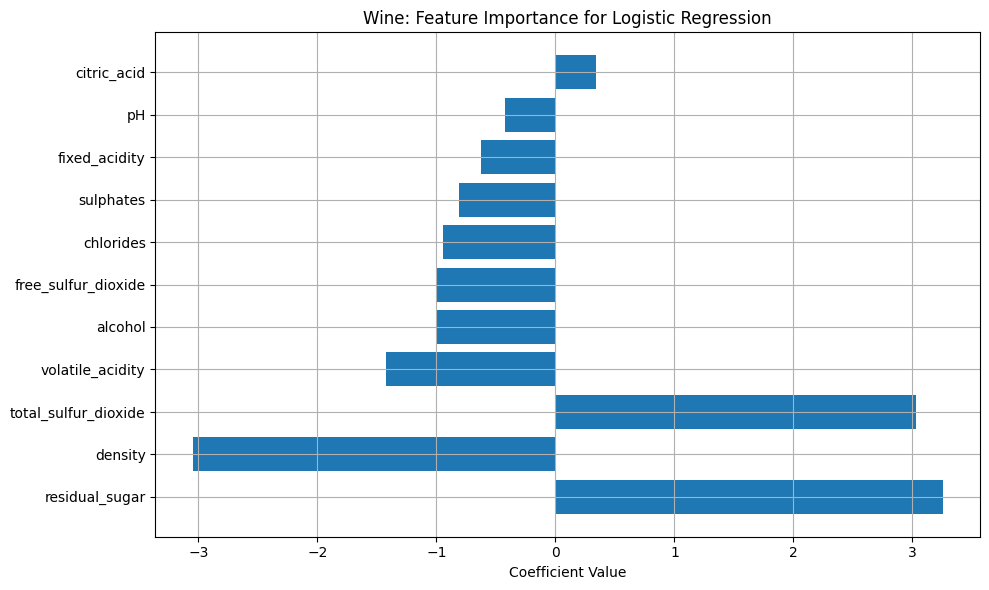

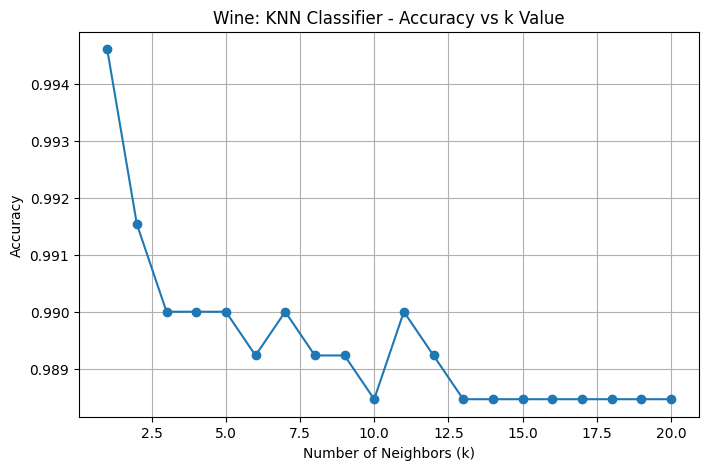

In [ ]:
# --------------------- Wine: CLASSIFICATION MODELS ---------------------
print("\n----- WINE COLOR CLASSIFICATION MODELS -----")

# Basic Wine KNN Classifier
herb_KNNClassifier = KNeighborsClassifier(n_neighbors=5)
herb_KNNClassifier.fit(X_color_train_wine, y_color_train_wine)

# Predict and evaluate
herb_y_color_pred_knn = herb_KNNClassifier.predict(X_color_test_wine)

# Calculate Wine classification metrics
herb_accuracy_knn = accuracy_score(y_color_test_wine, herb_y_color_pred_knn)
herb_conf_matrix_knn = confusion_matrix(y_color_test_wine, herb_y_color_pred_knn)
herb_class_report_knn = classification_report(y_color_test_wine, herb_y_color_pred_knn)

print("\nWine's KNN Classifier Results:")
print(f"Accuracy: {herb_accuracy_knn:.4f}")
print("\nConfusion Matrix:")
print(herb_conf_matrix_knn)
print("\nClassification Report:")
print(herb_class_report_knn)

# Wine Logistic Regression Classifier
print("\n--- Wine Logistic Regression Classifier ---")
herb_LogisticClassifier = LogisticRegression(max_iter=1000, random_state=42)
herb_LogisticClassifier.fit(X_color_train_wine, y_color_train_wine)

# Predict and evaluate
herb_y_color_pred_log = herb_LogisticClassifier.predict(X_color_test_wine)

# Calculate Wine classification metrics
herb_accuracy_log = accuracy_score(y_color_test_wine, herb_y_color_pred_log)
herb_conf_matrix_log = confusion_matrix(y_color_test_wine, herb_y_color_pred_log)
herb_class_report_log = classification_report(y_color_test_wine, herb_y_color_pred_log)

print(f"\nWine's Logistic Regression Accuracy: {herb_accuracy_log:.4f}")
print("\nWine Confusion Matrix:")
print(herb_conf_matrix_log)
print("\nWine Classification Report:")
print(herb_class_report_log)

# Compare feature importance for Wine Logistic Regression
herb_feature_importance = pd.DataFrame({
    'Feature': X_color_wine.columns,
    'Coefficient': herb_LogisticClassifier.coef_[0]
})
herb_feature_importance['Absolute_Importance'] = abs(herb_feature_importance['Coefficient'])
herb_feature_importance = herb_feature_importance.sort_values('Absolute_Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(herb_feature_importance['Feature'], herb_feature_importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Wine: Feature Importance for Logistic Regression')
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualize how k affects accuracy
herb_k_values = range(1, 21)
herb_accuracy_scores = []

for k in herb_k_values:
    herb_knn_temp = KNeighborsClassifier(n_neighbors=k)
    herb_knn_temp.fit(X_color_train_wine, y_color_train_wine)
    herb_y_pred_temp = herb_knn_temp.predict(X_color_test_wine)
    herb_accuracy_scores.append(accuracy_score(y_color_test_wine, herb_y_pred_temp))

plt.figure(figsize=(8, 5))
plt.plot(herb_k_values, herb_accuracy_scores, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Wine: KNN Classifier - Accuracy vs k Value')
plt.grid(True)
plt.show()

**DANIEL ZAMORA'S: GREENHOUSE DATASET**

**GREENHOUSE DATA-PREPROCESSING**

In [ ]:
# Load the Supply Chain dataset
df_green = pd.read_csv("SupplyChainGHGEmissionFactors_v1.2_NAICS_CO2e_USD2021.csv")
print(df_green.head())

# Check dataset columns
print("\nColumns in the dataset:")
print(df_green.columns)

# Copy of the dataset
df_green_copy = df_green.copy()

# Handle missing values
df_green.dropna(inplace=True)

for column in df_green.select_dtypes(include=['number']):
    df_green[column] = df_green[column].fillna(df_green[column].median())
for column in df_green.select_dtypes(include=['object']):
    df_green[column] = df_green[column].fillna(df_green[column].mode()[0])

# Encode categorical features
categorical_cols_green = df_green.select_dtypes(include=['object']).columns
df_green = pd.get_dummies(df_green, columns=categorical_cols_green, drop_first=True)

# Feature scaling
numerical_cols_green = df_green.select_dtypes(include=['number']).columns
numerical_cols_green = numerical_cols_green.drop('Supply Chain Emission Factors with Margins', errors='ignore')
scaler_green = StandardScaler()
df_green[numerical_cols_green] = scaler_green.fit_transform(df_green[numerical_cols_green])

# Discretize target variable
df_green['Emission_Class'] = pd.qcut(df_green['Supply Chain Emission Factors with Margins'],
                                     q=3, labels=['Low', 'Medium', 'High'])

# Train-test split
X_green = df_green.drop(['Supply Chain Emission Factors with Margins', 'Emission_Class'], axis=1)
y_green = df_green['Emission_Class']
X_train_green, X_test_green, y_train_green, y_test_green = train_test_split(
    X_green, y_green, test_size=0.2, random_state=42
)

   2017 NAICS Code                  2017 NAICS Title       GHG  \
0           111110                   Soybean Farming  All GHGs   
1           111120  Oilseed (except Soybean) Farming  All GHGs   
2           111130          Dry Pea and Bean Farming  All GHGs   
3           111140                     Wheat Farming  All GHGs   
4           111150                      Corn Farming  All GHGs   

                                Unit  \
0  kg CO2e/2021 USD, purchaser price   
1  kg CO2e/2021 USD, purchaser price   
2  kg CO2e/2021 USD, purchaser price   
3  kg CO2e/2021 USD, purchaser price   
4  kg CO2e/2021 USD, purchaser price   

   Supply Chain Emission Factors without Margins  \
0                                          1.223   
1                                          1.223   
2                                          2.874   
3                                          2.874   
4                                          2.874   

   Margins of Supply Chain Emission Factors  \
0 

**GREENHOUSE KNN CLASSIFIER**

In [ ]:
# --------------------- Greenhouse: KNN CLASSIFIER ---------------------

# Initialize and train Greenhouse KNN Classifier
knn_model_green = KNeighborsClassifier(n_neighbors=5)
knn_model_green.fit(X_train_green, y_train_green)

# Predictions and evaluation
y_pred_green = knn_model_green.predict(X_test_green)
accuracy_green = accuracy_score(y_test_green, y_pred_green)
report_green = classification_report(y_test_green, y_pred_green)

print(f"\nGreenhouse's KNN Classifier Accuracy: {accuracy_green}")
print("\nClassification Report:")
print(report_green)

# Hyperparameter tuning with RandomizedSearchCV

param_dist_green = {
    'n_neighbors': np.arange(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

random_search_green = RandomizedSearchCV(
    knn_model_green, param_distributions=param_dist_green, n_iter=10, cv=5, random_state=42
)
random_search_green.fit(X_train_green, y_train_green)

# Best model and evaluation
best_knn_green = random_search_green.best_estimator_
y_pred_best_green = best_knn_green.predict(X_test_green)
accuracy_best_green = accuracy_score(y_test_green, y_pred_best_green)
report_best_green = classification_report(y_test_green, y_pred_best_green)

print("\nBest KNN Classifier (Greenhouse):")
print(f"Accuracy: {accuracy_best_green}")
print("\nClassification Report:")
print(report_best_green)


Greenhouse's KNN Classifier Accuracy: 0.9411764705882353

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.92      0.96        62
         Low       0.95      0.93      0.94        60
      Medium       0.90      0.96      0.93        82

    accuracy                           0.94       204
   macro avg       0.95      0.94      0.94       204
weighted avg       0.94      0.94      0.94       204


Best KNN Classifier (Greenhouse):
Accuracy: 0.9656862745098039

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.95      0.98        62
         Low       0.98      0.95      0.97        60
      Medium       0.93      0.99      0.96        82

    accuracy                           0.97       204
   macro avg       0.97      0.96      0.97       204
weighted avg       0.97      0.97      0.97       204



**GREENHOUSE PCA VISUALIZATION**

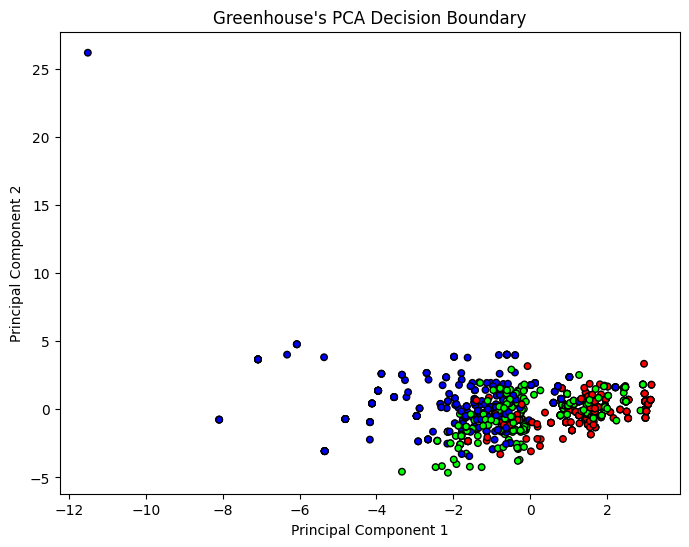

In [ ]:
# --------------------- Greenhouse: PCA VISUALIZATION ---------------------

# PCA transformation
scaler_pca_green = StandardScaler()
X_scaled_green = scaler_pca_green.fit_transform(X_green)
pca_green = PCA(n_components=2)
X_pca_green = pca_green.fit_transform(X_scaled_green)

# Meshgrid and decision boundary
x_min_green, x_max_green = X_pca_green[:, 0].min() - 1, X_pca_green[:, 0].max() + 1
y_min_green, y_max_green = X_pca_green[:, 1].min() - 1, X_pca_green[:, 1].max() + 1
x_step_green = (x_max_green - x_min_green) / 100
y_step_green = (y_max_green - y_min_green) / 100
xx_green, yy_green = np.meshgrid(np.arange(x_min_green, x_max_green, x_step_green),
                                 np.arange(y_min_green, y_max_green, y_step_green))

# Predict with KNN
meshgrid_original_green = pca_green.inverse_transform(np.c_[xx_green.ravel(), yy_green.ravel()])
meshgrid_df_green = pd.DataFrame(data=meshgrid_original_green, columns=X_green.columns)
Z_green = knn_model_green.predict(meshgrid_df_green)
Z_green = Z_green.reshape(xx_green.shape)

# Visualize
cmap_light_green = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold_green = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_green[:, 0], X_pca_green[:, 1], c=y_green.map({'Low': 0, 'Medium': 1, 'High': 2}),
            cmap=cmap_bold_green, edgecolor='k', s=22)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title("Greenhouse's PCA Decision Boundary")
plt.show()

**GREENHOUSE REGRESSION MODELS**

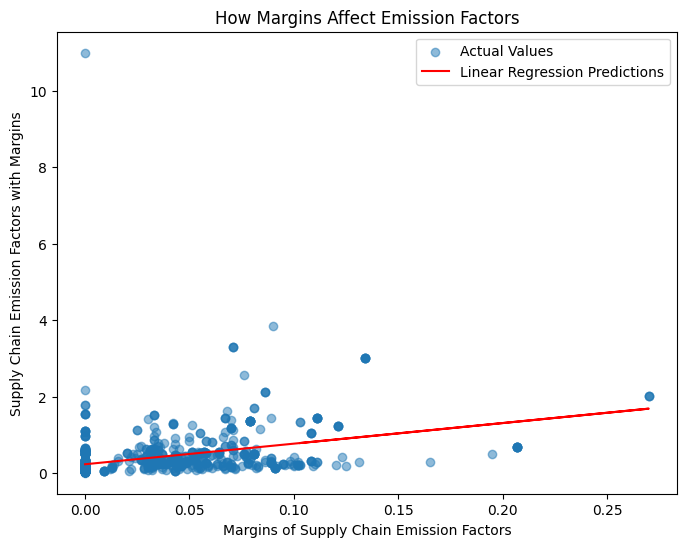


Greenhouse's Regression Metrics:
Linear Regression RMSE: 0.5261
Ridge Regression RMSE: 0.5263
Lasso Regression RMSE: 0.5696


In [ ]:
# --------------------- Greenhouse: REGRESSION MODELS ---------------------
# Prepare data for regression
df_all_green = pd.read_csv("SupplyChainGHGEmissionFactors_v1.2_NAICS_CO2e_USD2021.csv")
df_regression_green = df_all_green[['Margins of Supply Chain Emission Factors',
                                    'Supply Chain Emission Factors with Margins']].dropna()
X_regression_green = df_regression_green[['Margins of Supply Chain Emission Factors']]
y_regression_green = df_regression_green['Supply Chain Emission Factors with Margins']

# Linear Regression
linear_model_green = LinearRegression()
linear_model_green.fit(X_regression_green, y_regression_green)

# Ridge Regression with alpha=0.1
ridge_model_green = Ridge(alpha=0.1)
ridge_model_green.fit(X_regression_green, y_regression_green)

# Lasso Regression with alpha=0.1
lasso_model_green = Lasso(alpha=0.1)
lasso_model_green.fit(X_regression_green, y_regression_green)

# Visualize Linear Regression predictions
plt.figure(figsize=(8, 6))
plt.scatter(X_regression_green, y_regression_green, alpha=0.5, label="Actual Values")
plt.plot(X_regression_green, linear_model_green.predict(X_regression_green),
         color='r', label="Linear Regression Predictions")
plt.xlabel("Margins of Supply Chain Emission Factors")
plt.ylabel("Supply Chain Emission Factors with Margins")
plt.title("How Margins Affect Emission Factors")
plt.legend()
plt.show()

# Print Metrics

print("\nGreenhouse's Regression Metrics:")
print(f"Linear Regression RMSE: {np.sqrt(mean_squared_error(y_regression_green, linear_model_green.predict(X_regression_green))):.4f}")
print(f"Ridge Regression RMSE: {np.sqrt(mean_squared_error(y_regression_green, ridge_model_green.predict(X_regression_green))):.4f}")
print(f"Lasso Regression RMSE: {np.sqrt(mean_squared_error(y_regression_green, lasso_model_green.predict(X_regression_green))):.4f}")

**GREENHOUSE RIDGE REGRESSION TUNING**

In [ ]:
# --------------------- GREENHOUSE: RIDGE REGRESSION TUNING ---------------------

# Define Ridge model and parameter grid
param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0], 'fit_intercept': [True, False]}
ridge_grid_search_green = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='neg_mean_squared_error')
ridge_grid_search_green.fit(X_regression_green, y_regression_green)

# Best model and evaluation
best_ridge_green = ridge_grid_search_green.best_estimator_
print("\nGreenhouse's Best Ridge Regression Hyperparameters:")
print(ridge_grid_search_green.best_params_)

# Evaluate the best model
best_ridge_predictions_green = best_ridge_green.predict(X_regression_green)
rmse_best_ridge_green = np.sqrt(mean_squared_error(y_regression_green, best_ridge_predictions_green))
print(f"Best Ridge Regression RMSE: {rmse_best_ridge_green:.4f}")


Greenhouse's Best Ridge Regression Hyperparameters:
{'alpha': 0.01, 'fit_intercept': True}
Best Ridge Regression RMSE: 0.5261


**REGRESSION MODEL COMPARISON: ALL MODELS**


Regression Model Comparison:
                          Model  R² Score       MSE
0              Lung Elastic Net -0.000292  1.001059
1                      Lung KNN -0.092381  1.093219
2        Lung Linear Regression -0.000292  1.001059
3                      Wine KNN  0.332434  0.493029
4        Wine Linear Regression  0.259767  0.546696
5  GreenHouse Linear Regression  0.526119  0.276801
6   GreenHouse Ridge Regression  0.526263  0.276953
7   GreenHouse Lasso Regression  0.569565  0.324404


<Figure size 1200x800 with 0 Axes>

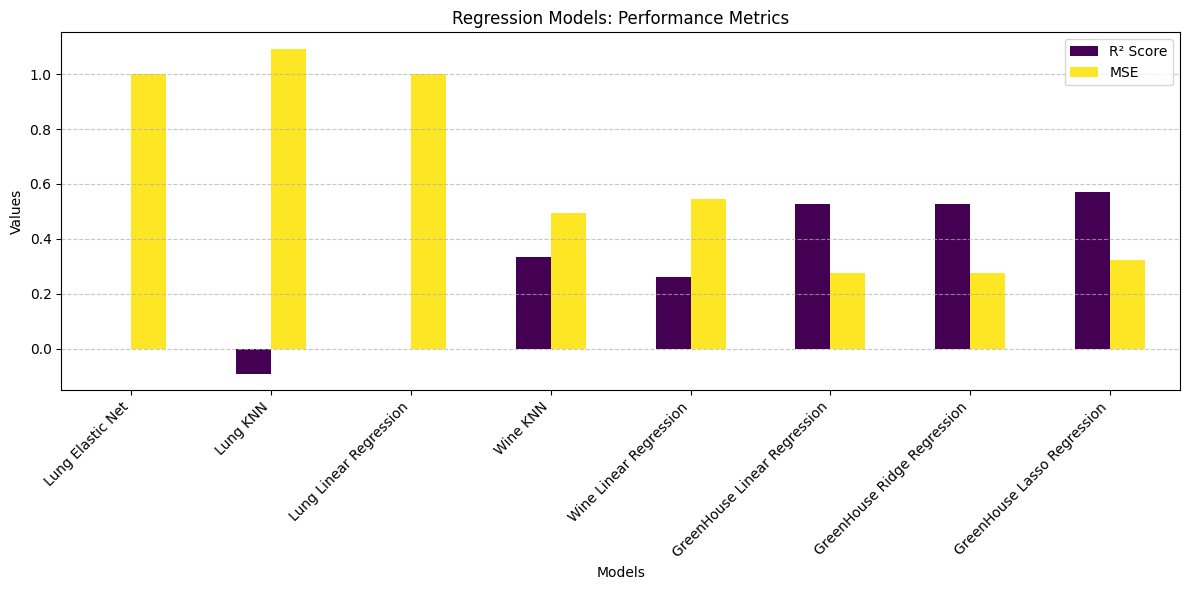

In [ ]:
# --------------------- REGRESSION MODEL COMPARISON ---------------------
# Consolidate results for all regression models
regression_comparison = {
    'Model': ['Lung Elastic Net', 'Lung KNN', 'Lung Linear Regression',
              "Wine KNN", "Wine Linear Regression",
              "GreenHouse Linear Regression", "GreenHouse Ridge Regression", "GreenHouse Lasso Regression"],
    'R² Score': [
        r2_score(y_test_linear, y_pred_elastic),
        r2_score(y_test_linear, y_pred_knn),
        r2_score(y_test_linear, elastic_best.predict(X_test_linear)),
        herb_r2_knn,
        herb_r2_lin,
        np.sqrt(mean_squared_error(y_regression_green, linear_model_green.predict(X_regression_green))),
        np.sqrt(mean_squared_error(y_regression_green, ridge_model_green.predict(X_regression_green))),
        np.sqrt(mean_squared_error(y_regression_green, lasso_model_green.predict(X_regression_green)))
    ],
    'MSE': [
        mean_squared_error(y_test_linear, y_pred_elastic),
        mean_squared_error(y_test_linear, y_pred_knn),
        mean_squared_error(y_test_linear, elastic_best.predict(X_test_linear)),
        herb_mse_knn,
        herb_mse_lin,
        mean_squared_error(y_regression_green, linear_model_green.predict(X_regression_green)),
        mean_squared_error(y_regression_green, ridge_model_green.predict(X_regression_green)),
        mean_squared_error(y_regression_green, lasso_model_green.predict(X_regression_green))
    ]
}
regression_df = pd.DataFrame(regression_comparison)
print("\nRegression Model Comparison:")
print(regression_df)

# Visualize regression comparison
plt.figure(figsize=(12, 8))
regression_df.set_index('Model')[['R² Score', 'MSE']].plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Regression Models: Performance Metrics')
plt.xlabel('Models')
plt.ylabel('Values')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

**CLASSIFICATION MODEL COMPARISON: ALL MODELS**


Classification Model Comparison:
                                 Model  Accuracy
0             Lung Logistic Regression  0.794750
1                  Lung KNN Classifier  0.871250
2                  Wine KNN Classifier  0.990000
3             Wine Logistic Regression  0.987692
4     GreenHouse KNN Classifier (Best)  0.965686
5  GreenHouse KNN Classifier (Default)  0.941176


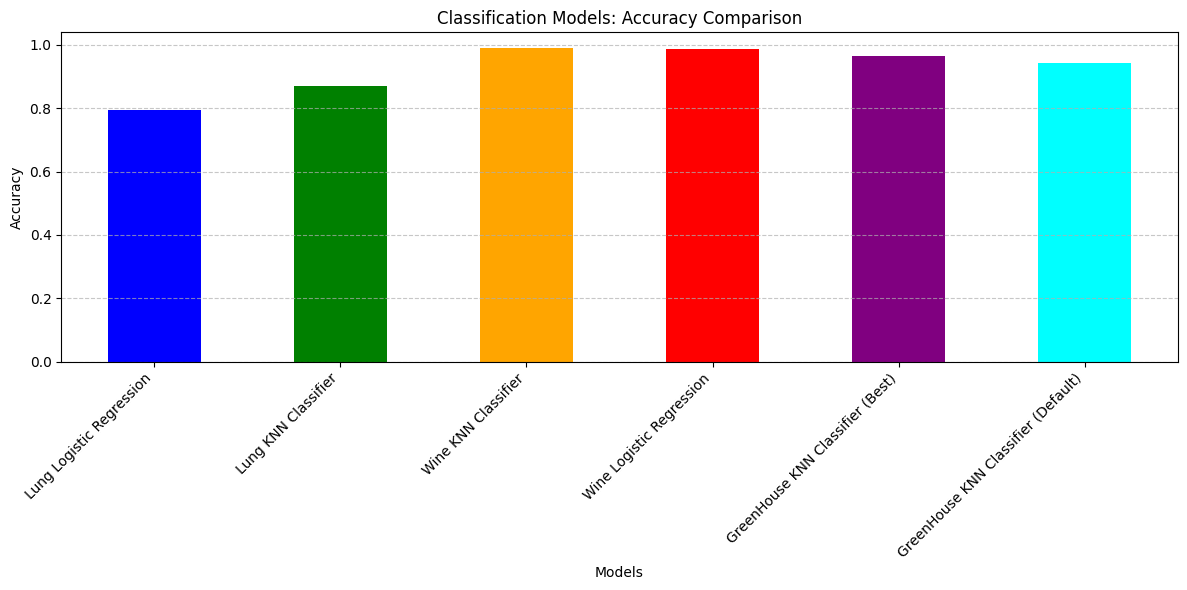

In [ ]:
# --------------------- CLASSIFICATION MODEL COMPARISON ---------------------
# Consolidate results for all classification models

# Apply threshold to y_pred_knn for consistency with y_test_logistic
threshold = 0.47
y_pred_knn_binary = np.where(knn.predict_proba(X_test_logistic)[:, 1] >= threshold, 'YES', 'NO')

classification_comparison = {
    'Model': ["Lung Logistic Regression", "Lung KNN Classifier",
              "Wine KNN Classifier", "Wine Logistic Regression",
              "GreenHouse KNN Classifier (Best)", "GreenHouse KNN Classifier (Default)"],
    'Accuracy': [
        accuracy_score(y_test_logistic, y_pred_logistic),
        accuracy_score(y_test_logistic, y_pred_knn_binary),  # Use the binary y_pred_knn
        herb_accuracy_knn,
        herb_accuracy_log,
        accuracy_best_green,
        accuracy_green
    ]
}
classification_df = pd.DataFrame(classification_comparison)
print("\nClassification Model Comparison:")
print(classification_df)

# Visualize classification comparison
plt.figure(figsize=(12, 8))
classification_df.set_index('Model')['Accuracy'].plot(kind='bar', figsize=(12, 6), color=['blue', 'green', 'orange', 'red', 'purple', 'cyan'])
plt.title('Classification Models: Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Confusion Matrix and Metrics: Evaluate Overfitting accross all Models**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Apply threshold to y_pred_knn for consistency with y_test_logistic
threshold = 0.47
y_pred_knn = np.where(knn.predict_proba(X_test_logistic)[:, 1] >= threshold, 'YES', 'NO')

# --------------------- Confusion Matrices and Metrics ---------------------
models_and_predictions = [
    ("Lung Logistic Regression", y_test_logistic, y_pred_logistic),
    ("Lung KNN Classifier", y_test_logistic, y_pred_knn),
    ("Wine KNN Classifier", y_color_test_wine, herb_y_color_pred_knn),
    ("Wine Logistic Regression", y_color_test_wine, herb_y_color_pred_log),
    ("GreenHouse KNN (Best)", y_test_green, y_pred_best_green),
    ("GreenHouse KNN (Default)", y_test_green, y_pred_green)
]

for model_name, y_test, y_pred in models_and_predictions:
    print(f"\n{model_name}:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


Lung Logistic Regression:
Confusion Matrix:
 [[  52  462]
 [ 359 3127]]

Classification Report:
               precision    recall  f1-score   support

          NO       0.13      0.10      0.11       514
         YES       0.87      0.90      0.88      3486

    accuracy                           0.79      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.78      0.79      0.78      4000


Lung KNN Classifier:
Confusion Matrix:
 [[   1  513]
 [   2 3484]]

Classification Report:
               precision    recall  f1-score   support

          NO       0.33      0.00      0.00       514
         YES       0.87      1.00      0.93      3486

    accuracy                           0.87      4000
   macro avg       0.60      0.50      0.47      4000
weighted avg       0.80      0.87      0.81      4000


Wine KNN Classifier:
Confusion Matrix:
 [[333   8]
 [  5 954]]

Classification Report:
               precision    recall  f1-score   support

         re

**Cross-Validation for all Models testing for Overfitting if large discrepancies.**

In [ ]:
# --------------------- Cross-Validation ---------------------
models_and_data = [
    ("Lung Logistic Regression", model_logistic, X_train_logistic, y_train_logistic),
    ("Lung KNN Classifier", knn, X_train_logistic, y_train_logistic),
    ("Wine KNN Classifier", herb_KNNClassifier, X_color_train_wine, y_color_train_wine),
    ("Wine Logistic Regression", herb_LogisticClassifier, X_color_train_wine, y_color_train_wine),
    ("GreenHouse KNN (Best)", best_knn_green, X_train_green, y_train_green),
    ("GreenHouse KNN (Default)", knn_model_green, X_train_green, y_train_green)
]

for model_name, model, X_train, y_train in models_and_data:
    print(f"\nCross-Validation Scores for {model_name}:")
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    print("CV Scores:", cv_scores)
    print("Mean CV Score:", cv_scores.mean())


Cross-Validation Scores for Lung Logistic Regression:
CV Scores: [0.50625   0.516875  0.5246875 0.5246875 0.5109375]
Mean CV Score: 0.5166875

Cross-Validation Scores for Lung KNN Classifier:
CV Scores: [0.87125   0.870625  0.8703125 0.8703125 0.87     ]
Mean CV Score: 0.8705

Cross-Validation Scores for Wine KNN Classifier:
CV Scores: [0.99326923 0.99230769 0.99615014 0.99037536 0.99807507]
Mean CV Score: 0.9940355001110536

Cross-Validation Scores for Wine Logistic Regression:
CV Scores: [0.99134615 0.99423077 0.99422522 0.99230029 0.99518768]
Mean CV Score: 0.9934580217664915

Cross-Validation Scores for GreenHouse KNN (Best):
CV Scores: [0.9202454  0.97546012 0.95679012 0.9691358  0.98765432]
Mean CV Score: 0.9618571536771945

Cross-Validation Scores for GreenHouse KNN (Default):
CV Scores: [0.88343558 0.96319018 0.94444444 0.96296296 0.95679012]
Mean CV Score: 0.9421646595470726


**Generalization Gap to detect more Overfitting**

In [ ]:
# --------------------- Generalization Gap ---------------------
for model_name, model, X_train, y_train, X_test, y_test in [
    ("Lung Logistic Regression", model_logistic, X_train_logistic, y_train_logistic, X_test_logistic, y_test_logistic),
    ("Lung KNN Classifier", knn, X_train_logistic, y_train_logistic, X_test_logistic, y_test_logistic),
    ("Wine KNN Classifier", herb_KNNClassifier, X_color_train_wine, y_color_train_wine, X_color_test_wine, y_color_test_wine),
    ("Wine Logistic Regression", herb_LogisticClassifier, X_color_train_wine, y_color_train_wine, X_color_test_wine, y_color_test_wine),
    ("GreenHouse KNN (Best)", best_knn_green, X_train_green, y_train_green, X_test_green, y_test_green),
    ("GreenHouse KNN (Default)", knn_model_green, X_train_green, y_train_green, X_test_green, y_test_green)
]:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(f"\nTraining Metrics for {model_name}:")
    print(classification_report(y_train, y_train_pred))

    print(f"\nTesting Metrics for {model_name}:")
    print(classification_report(y_test, y_test_pred))


Training Metrics for Lung Logistic Regression:
              precision    recall  f1-score   support

          NO       0.14      0.52      0.22      2054
         YES       0.88      0.52      0.66     13946

    accuracy                           0.52     16000
   macro avg       0.51      0.52      0.44     16000
weighted avg       0.78      0.52      0.60     16000


Testing Metrics for Lung Logistic Regression:
              precision    recall  f1-score   support

          NO       0.13      0.48      0.21       514
         YES       0.87      0.52      0.65      3486

    accuracy                           0.52      4000
   macro avg       0.50      0.50      0.43      4000
weighted avg       0.78      0.52      0.60      4000


Training Metrics for Lung KNN Classifier:
              precision    recall  f1-score   support

          NO       0.59      0.00      0.01      2054
         YES       0.87      1.00      0.93     13946

    accuracy                           0.87 